## Corrective Retrieval-Augmented Generation (CRAG)

**Corrective Retrieval-Augmented Generation (CRAG)** represents an advanced extension of the conventional Retrieval-Augmented Generation (RAG) paradigm. It introduces mechanisms for **self-assessment**, **self-correction**, and **adaptive retrieval**, thereby improving the factual reliability and contextual accuracy of generated responses.

As presented in the original [CRAG paper](https://arxiv.org/pdf/2401.15884), this framework emphasizes three key stages in its operation:

1. **Relevance Evaluation:**
   The retrieved documents are assessed based on their relevance to the input query. If at least one document surpasses a predefined relevance threshold, the system proceeds directly to the generation phase.

2. **Knowledge Refinement:**
   The system decomposes retrieved content into smaller **knowledge strips**, each of which is graded for quality and relevance. Irrelevant or low-confidence information is filtered out before response generation.

3. **Supplemental Retrieval:**
   In cases where no document meets the relevance criterion or when the model exhibits uncertainty, the framework performs **additional retrieval** from external sources—typically via web search—to enhance context coverage and ensure a comprehensive response.

---

### Implementation Architecture (LangGraph-Based Pipeline)

The implementation of CRAG in this study utilizes the **LangGraph** orchestration framework in conjunction with **LangChain** components. The overall workflow is divided into two major pipelines, as illustrated in the Mermaid diagram: **Data Ingestion** and **Query Processing**.

#### **1. Data Ingestion Pipeline**

The ingestion process prepares the foundational knowledge base for retrieval and generation:

* **Source Acquisition:**
  Textual content is sourced from *Lilian Weng’s technical blog posts* using LangChain’s `WebBaseLoader`.

* **Text Segmentation:**
  Each document is divided into manageable chunks using the `RecursiveCharacterTextSplitter` with a **chunk size of 1500** and **overlap of 300**, ensuring semantic continuity across segments.

* **Embedding Generation:**
  Semantic vector representations are computed using the **HuggingFace `all-mpnet-base-v2`** model, producing **768-dimensional embeddings**.

* **Vector Storage:**
  These embeddings are stored in a **Chroma Vector Database** (`rag-chroma-v2` collection), providing efficient similarity-based retrieval for subsequent queries.

---

#### **2. Query Processing Pipeline**

The runtime pipeline handles incoming user queries and dynamically adapts to ensure relevant and accurate responses:

1. **Retrieve Node:**
   Executes a similarity search (`k=12`) against the Chroma vector store to fetch potentially relevant documents.

2. **Rerank Node:**
   Applies **Cohere Rerank v3.0** to prioritize and retain the **top 6** documents most aligned with the query context.

3. **Grade Node:**
   Utilizes **Groq’s Llama-4-Scout-17B** model to assign binary relevance scores, facilitating a structured evaluation of document quality.

4. **Decision Node:**
   Determines whether retrieved documents exceed the predefined **relevance threshold (≥ 33%)**.

   * If **sufficient**, the process advances to the **Generation Node**.
   * If **insufficient**, corrective mechanisms are triggered through **query rewriting** and **supplemental retrieval**.

5. **Transform Node:**
   Refines or rephrases the user query using **Groq’s Llama-4-Scout-17B** to enhance retrieval precision.

6. **Web Search Node:**
   Invokes the **Tavily Search API** to collect additional external knowledge, limited to the **top 3 search results**.

7. **Merge Context Node:**
   Integrates both local (retrieved) and external (web-sourced) information to form a unified context base.

8. **Generate Node:**
   Produces the final response using **Groq’s Llama-4-Scout-17B** model with a **custom RAG generation prompt**, ensuring both factual grounding and coherence.

---

### Summary and Significance

This implementation demonstrates a practical realization of the **CRAG framework** through a modular, node-based architecture built with LangGraph. By combining document **grading**, **query transformation**, and **adaptive retrieval**, the system achieves:

* **Improved contextual relevance** through dynamic reranking and scoring.
* **Reduced hallucination** by enforcing threshold-based document filtering.
* **Enhanced completeness** via on-demand web augmentation.

Overall, this approach exemplifies a **self-corrective RAG pipeline** capable of maintaining high response fidelity, making it suitable for research-driven or production-grade knowledge-intensive applications.


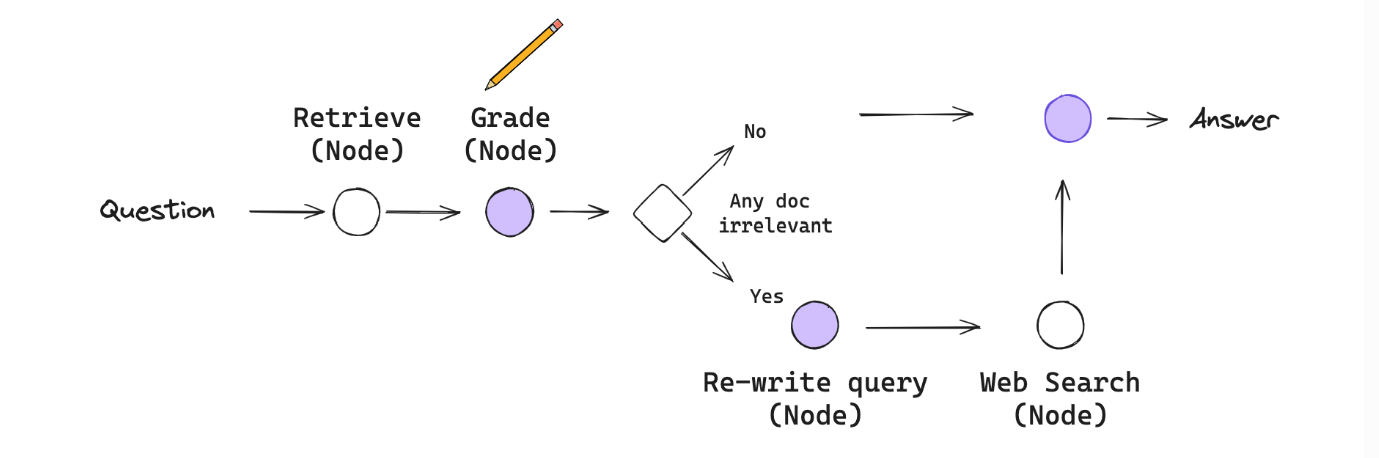

In [ ]:
# for snaps
from IPython.display import Image, display
display(Image("/content/Screenshot 2026-02-16 001948.png"))

##Enviornment setup:

In [1]:
! pip install -U langchain_community tiktoken langchain-groq langchain langchain-cohere cohere langchainhub langchain-chroma langchain langgraph tavily-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 

In [2]:
# Imports
from typing_extensions import TypedDict
from typing import List
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
# from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import SentenceTransformerEmbeddings
# from langchain import hub
# from langchainhub import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import END, StateGraph
# from langchain.schema import Document
from pprint import pprint
import os
from google.colab import userdata

##Tracing
- Optionally, use LangSmith for tracing (shown at bottom) by setting:

In [3]:
from google.colab import userdata
import os

# Set LangSmith environment variables
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "C-RAG notebook"

# Optional: Set LangSmith endpoint (usually not needed)
# os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

# Verify setup
print("LangSmith tracing enabled for project:", os.environ.get("LANGCHAIN_PROJECT"))

LangSmith tracing enabled for project: C-RAG notebook


In [4]:
### LLMs and APIs

# impors
# set all the required api keys in your colab secrets then load into notebook by this code:
# Get API key from Colab secrets
import os
from google.colab import userdata

try:
    from google.colab import userdata
    os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
    print("GROQ API key loaded successfully!")

    os.environ['COHERE_API_KEY'] = userdata.get("COHERE_API_KEY")
    print("COHERE API key loaded successfully!")

    os.environ['TAVILY_API_KEY'] = userdata.get("TAVILY_API_KEY")
    print("TAVILY API key loaded successfully!")

    print("All API keys loaded successfully!")
except Exception as e:
    print(f"Error loading API key: {e}")
    print("Please add your api's to Colab secrets (🔑 icon in left sidebar)")

GROQ API key loaded successfully!
COHERE API key loaded successfully!
TAVILY API key loaded successfully!
All API keys loaded successfully!



##Indexing
Let's index 3 blog posts

In [5]:
from langchain_community.document_loaders import WebBaseLoader
# from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# --- Indexing ---
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Add 'passage:' prefix for E5 embeddings
for doc in docs_list:
    doc.page_content = "passage: " + doc.page_content

# Split text
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=3000,
    chunk_overlap=1000
)
doc_splits = text_splitter.split_documents(docs_list)

# --- Embeddings ---
embedding = HuggingFaceEmbeddings(
    model_name="intfloat/e5-large-v2",
    encode_kwargs={"normalize_embeddings": True}
)

# --- Vector Store ---
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embedding
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 20})

/tmp/ipython-input-3111375206.py:28: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

In [6]:
# Check new chunk sizes
print(f"Total chunks: {len(doc_splits)}")
print(f"Average chunk length: {sum(len(chunk.page_content) for chunk in doc_splits) / len(doc_splits)}")

# Test retrieval
test_docs = retriever.invoke("types of agent memory")

for i, doc in enumerate(test_docs[:3]):
    print(f"\nRetrieved Doc {i}:")
    print(doc.page_content[:200])

Total chunks: 16
Average chunk length: 10550.625

Retrieved Doc 0:
passage: 





LLM Powered Autonomous Agents | Lil'Log







































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      LLM Powered 

Retrieved Doc 1:
Planning is essentially in order to optimize believability at the moment vs in time.
Prompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1)
Relationships between agents an

Retrieved Doc 2:
Describe what is quantum physics to a 6-year-old.

And safe content,

... in language that is safe for work.
In-context instruction learning (Ye et al. 2023) combines few-shot learning with instructio


##LLMs

In [7]:
### LLMs and APIs

# Data model for retrieval grader
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

llm_grader = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0
)
structured_llm_grader = llm_grader.with_structured_output(GradeDocuments)

# BALANCED grading prompt
system_grader_balanced = """You are a grader assessing relevance of a retrieved document to a user question.

A document is RELEVANT if it contains information that helps answer the question, including:
- Direct information about the topic, concept, or paper mentioned
- Related methods, techniques, or approaches that the topic uses
- Background information or context about similar systems
- Technical details about components or processes involved

A document is NOT RELEVANT if:
- It's about a completely different topic with no connection
- It only shares common technical terms but discusses unrelated concepts
- It provides no useful information toward answering the question

Be fair and practical: if the document contributes ANY useful information toward answering the question, mark it relevant.

Give a binary score 'yes' or 'no' to indicate whether the document is relevant to the question."""

grade_prompt_balanced = ChatPromptTemplate.from_messages([
    ("system", system_grader_balanced),
    ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
])

retrieval_grader = grade_prompt_balanced | structured_llm_grader

In [8]:
### Generate - SIMPLE VERSION WITHOUT TOOLS
llm_generate = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0
)

# Simple prompt without any tool configurations
simple_rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Keep the answer concise."""),
    ("human", """Question: {question}

Context: {context}

Answer:""")
])

def format_docs(docs):
    """Safely format documents, handling empty lists"""
    if not docs:
        return "No context available."
    return "\n\n".join(doc.page_content for doc in docs)

# Create chain WITHOUT .bind_tools() or any tool configurations
rag_chain = simple_rag_prompt | llm_generate | StrOutputParser()

In [9]:
### Question Re-writer
llm_rewrite = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

system_rewrite = """You are a question re-writer that converts an input question to a better version optimized for web search.
Look at the input and try to reason about the underlying semantic intent/meaning.
Expand any acronyms and add relevant context.

IMPORTANT: Return ONLY the reformulated question as a single sentence. No explanations."""

re_write_prompt = ChatPromptTemplate.from_messages([
    ("system", system_rewrite),
    ("human", "Original question: {question}\n\nReformulated question:"),
])

question_rewriter = re_write_prompt | llm_rewrite | StrOutputParser()

##Web Search Tool

In [10]:
### web search tool

web_search_tool = TavilySearchResults(k=3)

/tmp/ipython-input-4209836835.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)



##Graph
Capture the flow in as a graph.



###Graph state

In [ ]:
%%capture
"""
CRAG PIPELINE FLOW:
===================

┌─────────────────────────────────────────────────────────┐
│  1. RETRIEVE (k=12 docs from vector store)              │
└─────────────────┬───────────────────────────────────────┘
                  │
                  ▼
┌─────────────────────────────────────────────────────────┐
│  2. GRADE DOCUMENTS (check each doc's relevance)        │
│     - Mark each as "yes" or "no"                        │
│     - Calculate relevance ratio                         │
└─────────────────┬───────────────────────────────────────┘
                  │
                  ▼
┌─────────────────────────────────────────────────────────┐
│  3. DECISION POINT                                       │
│     Is relevance ratio >= 33% AND ≥2 relevant docs?    │
└─────────────────┬───────────────────────────────────────┘
                  │
         ┌────────┴────────┐
         │                 │
    YES  │                 │  NO
         │                 │
         ▼                 ▼
┌────────────────┐  ┌──────────────────────┐
│  4a. GENERATE  │  │  4b. TRANSFORM QUERY │
│  (local only)  │  │  (reformulate)       │
└────────┬───────┘  └──────────┬───────────┘
         │                     │
         │                     ▼
         │          ┌──────────────────────┐
         │          │  5. WEB SEARCH       │
         │          │  (get external docs) │
         │          └──────────┬───────────┘
         │                     │
         │                     ▼
         │          ┌──────────────────────┐
         │          │  6. MERGE            │
         │          │  (local + web docs)  │
         │          └──────────┬───────────┘
         │                     │
         │                     ▼
         │          ┌──────────────────────┐
         │          │  7. GENERATE         │
         │          │  (merged context)    │
         └──────────┴──────────┬───────────┘
                               │
                               ▼
                    ┌──────────────────┐
                    │   8. END         │
                    └──────────────────┘
"""

In [11]:
### Graph State
class GraphState(TypedDict):
    """Represents the state of our graph."""
    question: str
    generation: str
    web_search: str  # Changed from bool to str to match your usage
    documents: List[Document]
    all_retrieved_documents: List[Document]

In [23]:
from langchain_cohere import CohereRerank
from langchain_classic.retrievers import ContextualCompressionRetriever

# Create a reranker using your Cohere API
reranker = CohereRerank(model="rerank-english-v3.0", top_n=10)

# Wrap your retriever with reranking
compression_retriever = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=retriever
)

# Update the retrieve function
# Update your retrieve function to add query prefix
def retrieve(state):
    """Retrieve documents with reranking"""
    print("---RETRIEVE---")
    question = state["question"]

    # Add query prefix for E5 embeddings
    prefixed_question = "query: " + question

    # ✅ Fixed: use .invoke() instead of .get_relevant_documents()
    documents = compression_retriever.invoke(prefixed_question)

    print(f"\n📚 Retrieved and reranked {len(documents)} documents")
    for i, doc in enumerate(documents[:3]):
        content = doc.page_content.replace("passage: ", "")
        print(f"\nDoc {i+1} preview: {content[:150]}...")

    return {
        "documents": documents,
        "all_retrieved_documents": documents,
        "question": question
    }

In [24]:
def generate(state):
    """Generate answer from provided documents"""
    print("\n" + "="*60)
    print("✍️  GENERATING ANSWER")
    print("="*60)

    question = state["question"]
    documents = state["documents"]

    # EDGE CASE: No documents available
    if not documents or len(documents) == 0:
        print("\n⚠️  EDGE CASE: No documents available for generation!")
        print("💡 Generating answer based on LLM's general knowledge only")

        # Generate without context
        fallback_prompt = ChatPromptTemplate.from_messages([
            ("system", """You are a helpful AI assistant.
The user asked a question but no relevant context was found in the knowledge base or web search.
Provide a helpful response based on your general knowledge, but acknowledge that you don't have specific sources."""),
            ("human", "Question: {question}\n\nAnswer:")
        ])

        fallback_chain = fallback_prompt | llm_generate | StrOutputParser()
        generation = fallback_chain.invoke({"question": question})

        print(f"\n✅ Answer generated from general knowledge")
        print("="*60 + "\n")

        return {
            "documents": documents,
            "question": question,
            "generation": generation
        }

    # Normal case: Documents available
    # Separate local vs web docs for logging
    local_docs = [d for d in documents if d.metadata.get("source") != "web_search" and "search_rank" not in d.metadata]
    web_docs = [d for d in documents if d.metadata.get("source") == "web_search" or "search_rank" in d.metadata]

    print(f"\n📝 Question: {question}")
    print(f"\n📚 Context Summary:")
    print(f"   Local docs: {len(local_docs)}")
    print(f"   Web docs: {len(web_docs)}")
    print(f"   Total: {len(documents)}")

    if documents:
        print(f"\n📄 Preview of documents being used:")
        for i, doc in enumerate(documents[:3], 1):
            source = "🌐 WEB" if doc.metadata.get("source") == "web_search" or "search_rank" in doc.metadata else "💾 LOCAL"
            preview = doc.page_content[:200].replace('\n', ' ')
            print(f"\n{source} Doc {i}:")
            print(f"{preview}...")

    # Convert docs to string context
    context = format_docs(documents)

    # Generate answer with context
    try:
        generation = rag_chain.invoke({"context": context, "question": question})
    except Exception as e:
        print(f"❌ Generation error: {e}")
        # Fallback to simple generation
        generation = f"I encountered an error generating the response. Please try rephrasing your question."

    print(f"\n✅ Answer generated successfully!")
    print("="*60 + "\n")

    return {
        "documents": documents,
        "question": question,
        "generation": generation
    }

In [25]:
def grade_documents(state):
    """Grade document relevance to question"""
    print("\n" + "="*60)
    print("📋 CHECKING DOCUMENT RELEVANCE TO QUESTION")
    print("="*60)

    question = state["question"]
    documents = state["documents"]

    print(f"\n❓ Question: {question}")
    print(f"📚 Evaluating {len(documents)} documents...\n")

    filtered_docs = []
    web_search = "No"
    grading_errors = 0

    for idx, d in enumerate(documents, 1):
        # Show preview
        preview = d.page_content[:200].replace('\n', ' ')
        print(f"\n--- Document {idx}/{len(documents)} ---")
        print(f"Preview: {preview}...")

        # Grade with better error handling
        try:
            # Truncate very long documents that might cause issues
            doc_content = d.page_content[:4000]  # Limit to 4000 chars

            score = retrieval_grader.invoke({
                "question": question,
                "document": doc_content
            })
            grade = score.binary_score
        except Exception as e:
            print(f"⚠️  Grading error: {e}")
            grading_errors += 1
            grade = "no"  # Default to not relevant on error
            web_search = "Yes"  # Trigger web search if grading fails

        if grade == "yes":
            print("✅ GRADE: RELEVANT")
            filtered_docs.append(d)
        else:
            print("❌ GRADE: NOT RELEVANT")
            web_search = "Yes"

    print(f"\n{'='*60}")
    print(f"📊 GRADING SUMMARY: {len(filtered_docs)}/{len(documents)} documents marked relevant")

    if grading_errors > 0:
        print(f"⚠️  Grading errors encountered: {grading_errors}")

    # Handle edge case: NO relevant documents found
    if len(filtered_docs) == 0:
        print("⚠️  WARNING: No relevant documents found in local store!")
        print("🌐 Will proceed to web search for external information")
        web_search = "Yes"

    print(f"🌐 Web search needed: {web_search}")
    print(f"{'='*60}\n")

    return {
        "documents": filtered_docs,
        "question": question,
        "web_search": web_search
    }

In [26]:
def transform_query(state):
    """Transform the query to produce a better question for web search"""
    print("\n" + "="*60)
    print("🔄 TRANSFORMING QUERY")
    print("="*60)

    question = state.get("question", "").strip()
    if not question:
        raise ValueError("❌ No question found in state!")

    print(f"\n📝 Original question: {question}")

    try:
        # Safely call the LLM rewriter
        better_question = question_rewriter.invoke({"question": question})
    except Exception as e:
        print(f"⚠️ Query reformulation failed: {e}")
        # Fallback to the original question
        better_question = question

    print(f"✨ Reformulated question: {better_question}")
    print(f"\n💡 This optimized query will be used for web search")
    print("="*60 + "\n")

    return {"question": better_question}


In [27]:
def web_search(state):
    """Perform web search and merge with existing relevant documents"""
    print("\n" + "="*60)
    print("🌐 PERFORMING WEB SEARCH")
    print("="*60)

    question = state["question"]
    existing_docs = state.get("documents", [])  # Can be empty!

    print(f"📝 Question: {question}")
    print(f"📚 Existing relevant local docs: {len(existing_docs)}")

    if len(existing_docs) == 0:
        print("⚠️  No local context available - relying entirely on web search")

    # Perform web search
    try:
        search_results = web_search_tool.invoke({"query": question})
        print(f"🔍 Fetched {len(search_results)} web search results")
    except Exception as e:
        print(f"❌ Web search error: {e}")
        search_results = []

    # Convert search results to Documents
    web_documents = []
    for idx, d in enumerate(search_results, 1):
        if isinstance(d, str):
            web_documents.append(Document(
                page_content=d,
                metadata={"source": "web_search", "search_rank": idx}
            ))
        elif isinstance(d, dict):
            content = d.get("content", d.get("snippet", ""))
            if content:  # Only add if there's actual content
                web_documents.append(Document(
                    page_content=content,
                    metadata={
                        "source": d.get("url", "web_search"),
                        "search_rank": idx,
                        "title": d.get("title", "")
                    }
                ))

    # Merge: local relevant docs + web docs
    merged_documents = existing_docs + web_documents

    print(f"\n📊 MERGE SUMMARY:")
    print(f"   Local relevant docs: {len(existing_docs)}")
    print(f"   Web search docs: {len(web_documents)}")
    print(f"   Total merged docs: {len(merged_documents)}")

    # Edge case: No documents at all (neither local nor web)
    if len(merged_documents) == 0:
        print("⚠️  WARNING: No documents available for generation!")

    print("="*60 + "\n")

    return {
        "documents": merged_documents,  # Could still be empty in worst case
        "question": question
    }

In [28]:
def decide_to_generate(state):
    """
    Determines whether to generate directly or go through query reformulation + web search

    CRAG Logic:
    - If relevance >= 33% AND ≥2 docs: Generate directly from local context
    - If relevance < 33% OR <2 docs: Transform query → Web search → Generate
    - If 0 relevant docs: MUST go to web search
    """
    filtered_documents = state["documents"]
    total_docs = len(state.get("all_retrieved_documents", filtered_documents))
    relevant_count = len(filtered_documents)

    # Handle edge case: zero total docs (shouldn't happen, but be safe)
    if total_docs == 0:
        total_docs = 1  # Avoid division by zero

    relevance_ratio = relevant_count / total_docs
    web_search_flag = state.get("web_search", "No")

    print("\n" + "="*60)
    print("🤔 DECISION POINT: Should we generate or search?")
    print("="*60)
    print(f"\n📊 Relevance Analysis:")
    print(f"   Total retrieved: {total_docs}")
    print(f"   Marked relevant: {relevant_count}")
    print(f"   Relevance ratio: {relevance_ratio:.1%}")
    print(f"   Threshold: 33%")
    print(f"   Any irrelevant docs found: {web_search_flag}")

    # EDGE CASE: No relevant documents at all
    if relevant_count == 0:
        print(f"\n⚠️  EDGE CASE: Zero relevant documents!")
        print(f"❌ DECISION: TRANSFORM QUERY + WEB SEARCH (MANDATORY)")
        print(f"   Reason: No local context available")
        print(f"   Action: Must search external sources")
        print("="*60 + "\n")
        return "transform_query"

    # CRAG Decision Logic (normal cases)
    if relevance_ratio >= 0.33 and relevant_count >= 2 and web_search_flag == "No":
        print(f"\n✅ DECISION: GENERATE")
        print(f"   Reason: Sufficient local context ({relevance_ratio:.1%} ≥ 33%)")
        print(f"   Action: Generate answer directly from local documents")
        print("="*60 + "\n")
        return "generate"
    else:
        print(f"\n❌ DECISION: TRANSFORM QUERY + WEB SEARCH")
        print(f"   Reason: Insufficient local context ({relevance_ratio:.1%} < 33%)")
        print(f"   Action: Reformulate → Web Search → Merge → Generate")

        # Show specific reasons
        if relevance_ratio < 0.33:
            print(f"   • Relevance ratio {relevance_ratio:.1%} below 33% threshold")
        if relevant_count < 2:
            print(f"   • Only {relevant_count} relevant doc(s), need at least 2")
        if web_search_flag == "Yes":
            print(f"   • Some documents were marked irrelevant")

        print("="*60 + "\n")
        return "transform_query"


##Build Graph
The just follows the flow we outlined in the figure above.

In [29]:
## Build Graph
workflow = StateGraph(GraphState)

workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search_node", web_search)

workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()

In [30]:
from pprint import pprint

# Run
inputs = {"question": "What are the types of agent memory?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---

📚 Retrieved and reranked 10 documents

Doc 1 preview: 





LLM Powered Autonomous Agents | Lil'Log







































Lil'Log

















|






Posts




Archive




Search



...

Doc 2 preview: After fine-tuning with CoH, the model can follow instructions to produce outputs with incremental improvement in a sequence. (Image source: Liu et al....

Doc 3 preview: Illustration of how HuggingGPT works. (Image source: Shen et al. 2023)

The system comprises of 4 stages:
(1) Task planning: LLM works as the brain an...
"Node 'retrieve':"
'\n---\n'

📋 CHECKING DOCUMENT RELEVANCE TO QUESTION

❓ Question: What are the types of agent memory?
📚 Evaluating 10 documents...


--- Document 1/10 ---
Preview: passage:       LLM Powered Autonomous Agents | Lil'Log                                        Lil'Log                  |       Posts     Archive     Search     Tags     FAQ                LLM Powered ...
✅ GRADE: RELEVANT

--- Document 2/10 ---
Preview:

In [31]:
from pprint import pprint

# Run
inputs = {"question": "How does the AlphaCodium paper work?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---

📚 Retrieved and reranked 10 documents

Doc 1 preview: - Each API call is represented as a tuple of (API name, corresponding input), $c=(a_c, i_c)$ and its corresponding result is denoted as $r$. The API c...

Doc 2 preview: After fine-tuning with CoH, the model can follow instructions to produce outputs with incremental improvement in a sequence. (Image source: Liu et al....

Doc 3 preview: Use an iterative Monte Carlo search method to improve the best candidates by proposing semantically similar variants via prompts like Generate a varia...
"Node 'retrieve':"
'\n---\n'

📋 CHECKING DOCUMENT RELEVANCE TO QUESTION

❓ Question: How does the AlphaCodium paper work?
📚 Evaluating 10 documents...


--- Document 1/10 ---
Preview: - Each API call is represented as a tuple of (API name, corresponding input), $c=(a_c, i_c)$ and its corresponding result is denoted as $r$. The API call sequences with and without results are labeled...
❌ GRADE: NOT RELEVANT

--- Document 2/10 ---
Pre

In [32]:
import gradio as gr
from typing import Generator
import time

def process_query(question: str, history: list) -> Generator[str, None, None]:
    """
    Process user query through CRAG pipeline with streaming updates

    Args:
        question: User's question
        history: Chat history (not used but required by Gradio)

    Yields:
        Streaming updates showing pipeline progress and final answer
    """

    # Initialize response
    response = ""

    try:
        # Step 1: RETRIEVE
        response += "## 🔍 Step 1: Retrieving Documents\n"
        response += "Searching vector store...\n\n"
        yield response
        time.sleep(0.5)

        # Run retrieval
        inputs = {"question": question}
        state = None

        for output in app.stream(inputs):
            for key, value in output.items():
                state = value

                # RETRIEVE node
                if key == "retrieve":
                    docs = value.get("documents", [])
                    response += f"✅ Retrieved {len(docs)} documents\n\n"
                    yield response
                    time.sleep(0.3)

                # GRADE DOCUMENTS node
                elif key == "grade_documents":
                    filtered_docs = value.get("documents", [])
                    all_docs = value.get("all_retrieved_documents", [])
                    relevance_ratio = len(filtered_docs) / len(all_docs) if all_docs else 0

                    response += "## 📋 Step 2: Evaluating Relevance\n"
                    response += f"- Total documents: {len(all_docs)}\n"
                    response += f"- Relevant documents: {len(filtered_docs)}\n"
                    response += f"- Relevance ratio: {relevance_ratio:.1%}\n\n"
                    yield response
                    time.sleep(0.3)

                    # Show decision
                    web_search_flag = value.get("web_search", "No")
                    if relevance_ratio >= 0.33 and len(filtered_docs) >= 2 and web_search_flag == "No":
                        response += "✅ **Decision**: Sufficient local context - generating answer\n\n"
                    else:
                        response += "⚠️ **Decision**: Insufficient context - will search web\n\n"
                    yield response
                    time.sleep(0.3)

                # TRANSFORM QUERY node
                elif key == "transform_query":
                    reformulated = value.get("question", "")
                    response += "## 🔄 Step 3: Query Reformulation\n"
                    response += f"**Original**: {question}\n\n"
                    response += f"**Reformulated**: {reformulated}\n\n"
                    yield response
                    time.sleep(0.3)

                # WEB SEARCH node
                elif key == "web_search_node":
                    docs = value.get("documents", [])
                    local_docs = [d for d in docs if d.metadata.get("source") != "web_search"]
                    web_docs = [d for d in docs if d.metadata.get("source") == "web_search"]

                    response += "## 🌐 Step 4: Web Search & Merge\n"
                    response += f"- Local docs: {len(local_docs)}\n"
                    response += f"- Web docs: {len(web_docs)}\n"
                    response += f"- **Total context**: {len(docs)} documents\n\n"
                    yield response
                    time.sleep(0.3)

                # GENERATE node
                elif key == "generate":
                    response += "## ✍️ Step 5: Generating Answer\n"
                    response += "Synthesizing response from context...\n\n"
                    yield response
                    time.sleep(0.5)

                    # Add final answer
                    generation = value.get("generation", "")
                    response += "---\n\n"
                    response += "## 💡 Final Answer\n\n"
                    response += generation + "\n"
                    yield response

        # If no generation in state, show error
        if state and "generation" not in state:
            response += "\n\n⚠️ Could not generate answer. Please try again."
            yield response

    except Exception as e:
        response += f"\n\n❌ **Error**: {str(e)}\n"
        response += "Please try rephrasing your question or check the system logs."
        yield response


# Create Gradio interface
with gr.Blocks(theme=gr.themes.Soft(), title="CRAG System Demo") as demo:

    gr.Markdown(
        """
        # 🤖 CRAG System - Corrective Retrieval Augmented Generation

        This system intelligently retrieves information from a local knowledge base and augments
        with web search when needed to provide accurate, comprehensive answers.

        ### How it works:
        1. **Retrieve** - Searches vector store for relevant documents
        2. **Grade** - Evaluates document relevance to your question
        3. **Decide** - Determines if local context is sufficient or if web search is needed
        4. **Augment** - (If needed) Reformulates query and searches the web
        5. **Generate** - Creates a comprehensive answer from all available context
        """
    )

    with gr.Row():
        with gr.Column(scale=2):
            chatbot = gr.Chatbot(
                label="CRAG Assistant",
                height=500,
                show_label=True,
                avatar_images=(None, "🤖"),
            )

            with gr.Row():
                question_input = gr.Textbox(
                    label="Ask a question",
                    placeholder="E.g., What are the types of agent memory?",
                    lines=2,
                    scale=4
                )
                submit_btn = gr.Button("🔍 Ask", variant="primary", scale=1)

            gr.Examples(
                examples=[
                    "What are the types of agent memory?",
                    "How does the AlphaCodium paper work?",
                    "Explain Chain of Hindsight (CoH) fine-tuning",
                    "What is HuggingGPT and how does it work?",
                    "What are adversarial attacks on LLMs?",
                ],
                inputs=question_input,
                label="Example Questions"
            )

        with gr.Column(scale=1):
            gr.Markdown(
                """
                ### 📊 System Status

                **Knowledge Base**:
                - LLM Agents
                - Prompt Engineering
                - Adversarial Attacks

                **Capabilities**:
                - ✅ Local retrieval with reranking
                - ✅ Relevance grading
                - ✅ Query reformulation
                - ✅ Web search augmentation
                - ✅ Context merging

                **Model**: Llama 4 Scout (via Groq)

                **Retrieval**:
                - E5 embeddings
                - Cohere reranking
                - Chroma vector store

                **Web Search**: Tavily API
                """
            )

            clear_btn = gr.Button("🗑️ Clear Chat", variant="secondary")

    gr.Markdown(
        """
        ---
        ### 💡 Tips:
        - Ask questions about LLM agents, prompting techniques, or AI security
        - The system will show you each step of the retrieval and generation process
        - If local knowledge is insufficient, it will automatically search the web
        - Try different questions to see how the system adapts its strategy
        """
    )

    # Event handlers
    def user_message(message, history):
        """Add user message to chat"""
        return "", history + [[message, None]]

    def bot_response(history):
        """Generate bot response with streaming"""
        user_message = history[-1][0]
        history[-1][1] = ""

        for chunk in process_query(user_message, history):
            history[-1][1] = chunk
            yield history

    # Submit on button click
    submit_btn.click(
        user_message,
        inputs=[question_input, chatbot],
        outputs=[question_input, chatbot],
        queue=False
    ).then(
        bot_response,
        inputs=[chatbot],
        outputs=[chatbot]
    )

    # Submit on Enter key
    question_input.submit(
        user_message,
        inputs=[question_input, chatbot],
        outputs=[question_input, chatbot],
        queue=False
    ).then(
        bot_response,
        inputs=[chatbot],
        outputs=[chatbot]
    )

    # Clear chat
    clear_btn.click(lambda: None, None, chatbot, queue=False)

# Launch the interface
if __name__ == "__main__":
    demo.queue()  # Enable queuing for streaming
    demo.launch(
        share=True,  # Creates a public link
        server_name="0.0.0.0",  # Makes it accessible
        server_port=7861,  # Default Gradio port
        show_error=True
    )

/tmp/ipython-input-3754636128.py:112: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="CRAG System Demo") as demo:
/tmp/ipython-input-3754636128.py:132: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipython-input-3754636128.py:132: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1cbfbe040c5b72e52a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
